#### Data Processing with Python

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


###### IN CASE OF PROBLEMS IMPORTING PACKAGES


In [ ]:
# SOLUTION A: select this cell and type Shift-Enter to execute the code below.

%conda install openpyxl pandas seaborn

# Now restart the kernel (Menu -> Kernel -> Restart Kernel)

In [2]:
# SOLUTION B: select this cell and type Shift-Enter to execute the code below.

%pip install openpyxl pandas seaborn

# Now restart the kernel (Menu -> Kernel -> Restart Kernel)

  Using cached pandas-2.2.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (89 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 16.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 15.3 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 15.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 15.5 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

# Final Exam

The file `cell_phones.csv` contains data on the number of mobile phone subscriptions active in various countries across time.

This notebook contains some tasks for you to complete on this dataset.


---
## 1.
Load the cell phone data and reshape the resulting dataframe to a tidy form.

In [ ]:
cell_phones = pd.read_csv("cell_phones.csv")
cell_phones.head()
cell_phones = cell_phones.melt(id_vars=['country'], var_name='year', value_name='subscriptions')
cell_phones = cell_phones.dropna()
cell_phones['year'] = cell_phones['year'].astype(int)

## 2.
Draw a line graph showing the number of mobile phone contracts in the UK from 2000 to 2023

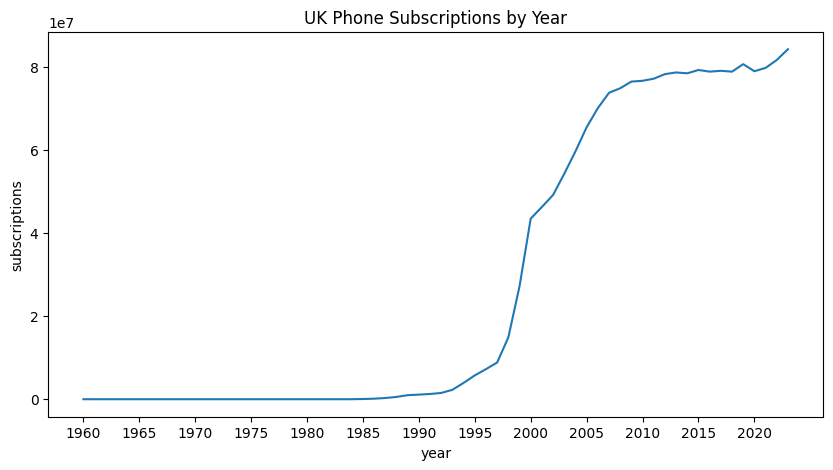

In [35]:
UK = cell_phones[cell_phones['country'] == 'UK']

plt.figure(figsize=(10, 5))
ax = sns.lineplot(data=UK, x='year', y='subscriptions')
ax.set(title='UK Phone Subscriptions by Year')
ax.set_xticks(range(UK['year'].min(), UK['year'].max() + 1, 5))
plt.show()

## 3.
Show that the total global number of mobile phone contracts in 2023 was 6.9 billion.

In [43]:
print("Total global number of phone contracts in 2023:", sum(cell_phones[cell_phones['year'] == 2023]['subscriptions']) / 10.0**9, "billion")

Total global number of phone contracts in 2023: 6.875049796 billion


## 4.
Using additional data from the sheet `list-of-countries-etc` from the Excel workbook `data_geographies_v1.xlsx`, calculate the total number of contracts in 2023 for the four regions Asia, Europe, Africa and the Americas.

/var/folders/f0/z6np3ydj4kb14r8xlcyyq94r0000gp/T/ipykernel_94262/4163341391.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_info['name'] = region_info['name'].replace({


<Axes: xlabel='four_regions', ylabel='subscriptions'>

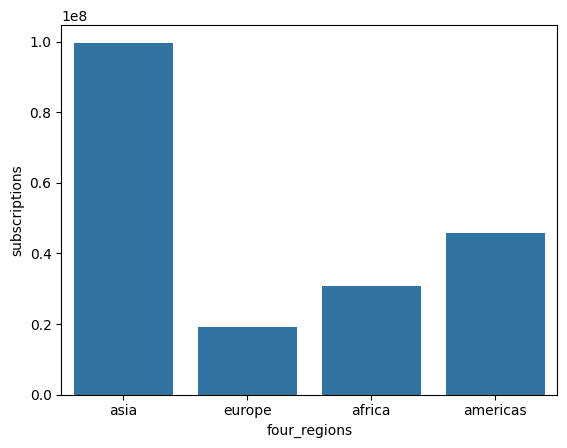

In [ ]:
cell_phones_2023 = cell_phones[cell_phones['year'] == 2023]
# display(cell_phones_2023)

countries = pd.read_excel("data_geographies_v1.xlsx", sheet_name = "list-of-countries-etc")
# display(countries)
region_info = countries[['name', 'four_regions']]

mismatched_countries = cell_phones_2023['country'][~cell_phones_2023['country'].isin(countries['name'])]
# display(mismatched_countries)


region_info['name'] = region_info['name'].replace({
    'United Kingdom' : 'UK',
    'United States' : 'USA',
    'United Arab Emirates' : 'UAE'
})

cell_phones_2023 = cell_phones_2023.set_index('country')
region_info = region_info.set_index('name')

merged_dt = cell_phones_2023.join(region_info)
merged_dt = merged_dt.dropna()
# display(merged_dt)

sns.barplot(x="four_regions",y="subscriptions",data=merged_dt, errorbar=None)

***